# Decoding brain regions from single neurons, pair by pair

Posani, Wang et al. (2026) ask whether a neuron's response profile says where the neuron is.
Their released multi-area script (`clustering-analysis/multi_area/Fig3ef.py`) answers it by
clustering the neurons and scoring the clusters against the area labels with a Rand index.

This notebook puts the same question to a **decoder**, one pair of regions at a time: given the
encoding profile of a single neuron, which of the two regions is it from? A pair is the right
unit because a pair is what the anatomy is defined on -- two regions have a distance along the
cortical hierarchy, an anatomical connectivity, and a Procrustes shape distance -- so the
decoding accuracy can be put against all of them.

Four steps:

1. the pairwise decoding matrix, against a label shuffle and a within-region floor
2. the cortical hierarchy: pair by pair, and region by region
3. anatomical connectivity
4. what predicts decodability once the candidates compete
5. one summary figure

Everything is reused: the data through `code/data.py`, the pairwise decoder in
`code/decoding.py`, the shape distances and the cross-validation in `code/shape.py`, and the
panel style in `code/plotting.py`. Run `extract_selectivity.py` once first to produce
`rrr_neurons.npz`. Every matrix is cached under `results/pair_decoding/`, so a re-run is instant.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "code")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

import data, decoding, shape, plotting

OUT = Path("results/pair_decoding")
OUT.mkdir(parents=True, exist_ok=True)


def cached(name, compute):
    '''Every matrix here costs minutes, and none of them depends on the analysis.'''
    f = OUT / f"{name}.npy"
    if f.exists():
        return np.load(f)
    a = compute()
    np.save(f, a)
    return a


d = data.Dataset()
K = len(d.regions)
ii, jj = np.triu_indices(K, 1)
print(d)
print(", ".join(f"{a}({n})" for a, n in zip(d.regions, d.counts)))

Dataset(4617 selective neurons, 22 regions)
VISp(160), AUDp(164), SSp-ll(74), SSp-n(191), SSp-ul(100), SSp-m(465), SSp-bfd(185), SSs(269), SSp-tr(92), MOp(754), RSPv(87), RSPd(68), GU(76), ORBl(67), AId(144), VISpm(77), PL(103), VISa(316), VISam(76), MOs(383), ORBvl(121), ACAd(120)


## 1. The pairwise decoding matrix

For every one of the 231 pairs of regions, a standardised logistic regression is trained to tell
a neuron of one region from a neuron of the other, and scored by 5-fold cross-validation. The
features are the eight selectivity coefficients $\alpha_v = \sum_t |\beta_{vt}|$ -- the
*selectivity space* of the paper's Fig. 3e-f.

**Both regions are subsampled to 50 neurons before each pair is decoded**, and the matrix
averaged over 20 draws. That is the same protection `shape.distance_matrix` applies to the shape
distances, and it does two things at once here: chance is exactly 0.5 whatever the two regions'
sizes, and no pair gets more training data than another. Without it, a pair containing a large
region would look more decodable simply because it was fitted on more neurons.

Two references, because "above 0.5" is not by itself the interesting comparison:

- **the label shuffle** -- the same estimator and the same folds with the labels permuted. It
  measures how much accuracy the cross-validation itself hands out for free at this sample size.
- **the within-region floor** -- an arbitrary split of one region's neurons into two halves,
  decoded against each other. Unlike the shuffle it keeps the labels attached to the neurons, so
  anything it finds is real structure *inside* a region. It is necessarily run at 25 neurons per
  side rather than 50: several regions have barely more than the 50 selective neurons the paper's
  own criterion demands, and two disjoint halves of 50 would need 100.

In [2]:
A = cached("A_sel", lambda: decoding.decoding_matrix(d))                     # ~3 min
A_shuf = cached("A_shuf", lambda: decoding.decoding_matrix(d, shuffle=True))  # ~3 min
floor = cached("splithalf", lambda: decoding.split_half(d))

acc, chance = A[ii, jj], A_shuf[ii, jj]
print(f"pairwise accuracy   {acc.mean():.3f}  (range {acc.min():.3f} to {acc.max():.3f})")
print(f"label shuffle       {chance.mean():.3f} +/- {chance.std():.3f}")
print(f"within-region floor {floor.mean():.3f} +/- {floor.std():.3f}")
print(f"{(acc > chance.mean() + 2 * chance.std()).sum()}/{len(acc)} pairs past the shuffle's "
      f"mean + 2 sd, {(acc > floor.mean() + 2 * floor.std()).sum()}/{len(acc)} past the floor's")

o = np.argsort(acc)
name = lambda k: f"{d.regions[ii[k]]}-{d.regions[jj[k]]}"
print("\nleast decodable: " + ", ".join(f"{name(k)} {acc[k]:.2f}" for k in o[:5]))
print("most decodable:  " + ", ".join(f"{name(k)} {acc[k]:.2f}" for k in o[-5:][::-1]))

pairwise accuracy   0.705  (range 0.508 to 0.873)
label shuffle       0.498 +/- 0.014
within-region floor 0.501 +/- 0.020
228/231 pairs past the shuffle's mean + 2 sd, 226/231 past the floor's

least decodable: PL-ORBvl 0.51, MOs-ACAd 0.52, SSp-tr-PL 0.52, SSp-tr-VISa 0.53, PL-VISa 0.53
most decodable:  SSp-n-AId 0.87, SSp-n-ORBl 0.87, SSp-ll-GU 0.86, SSp-n-ACAd 0.86, SSp-n-MOs 0.85


Region identity is carried by **single neurons**, and strongly: 0.71 on average, up to 0.87 for
the easiest pair, against a shuffle at 0.50 and a within-region split that is flat at 0.50. The
floor is the informative one -- splitting a region's own neurons in two yields nothing, so what
the decoder finds between two regions is not generic structure that any partition of neurons
would expose.

This is not in tension with the paper's clustering result. A decoder needs only that the two
clouds of response profiles have different *distributions*; clustering asks the much stronger
question of whether the profiles fall into discrete types. Regions can be highly separable and
not at all categorical, which is exactly the paper's title.

## 2. Does decodability follow the cortical hierarchy?

`area_list.csv` orders the cortical areas from sensory to associative, so a region's index in it
*is* its position in the hierarchy, and `d.hierarchy()` returns it. Two different questions can
be asked of a pair:

- $|\Delta h|$, how far apart the two regions sit -- if the hierarchy is a gradient of response
  profiles, regions further apart on it should be easier to tell apart;
- $\bar h$, how high up the pair sits on average -- whether regions become more, or less,
  individual as one moves away from the sensory periphery.

Both are reported with a permutation null that relabels the regions. It is not optional: the 231
pairs are built from 22 regions, so they are far from independent, and a plain Spearman $p$ on
231 points would be badly overconfident. Permuting region labels destroys the link between
identity and decodability while leaving the pair structure exactly as it is.

In [3]:
h = d.hierarchy()
dh, mh = np.abs(h[ii] - h[jj]), (h[ii] + h[jj]) / 2

rng = np.random.default_rng(0)
N_PERM = 2000


def perm_rho(x_of_perm, y=acc, n_perm=N_PERM):
    '''Spearman rho against relabelled regions: the pair structure is left intact.'''
    rho = spearmanr(x_of_perm(np.arange(K)), y)[0]
    null = np.array([spearmanr(x_of_perm(rng.permutation(K)), y)[0] for _ in range(n_perm)])
    p = (np.sum(np.abs(null) >= abs(rho)) + 1) / (n_perm + 1)
    return rho, null, p


rho_dh, null_dh, p_dh = perm_rho(lambda p_: np.abs(h[p_][ii] - h[p_][jj]))
rho_mh, null_mh, p_mh = perm_rho(lambda p_: (h[p_][ii] + h[p_][jj]) / 2)
print(f"accuracy vs |dh|, distance along the hierarchy: rho = {rho_dh:+.2f}, p = {p_dh:.4f}")
print(f"accuracy vs mean h, height in the hierarchy:    rho = {rho_mh:+.2f}, p = {p_mh:.4f}")
print("  (naive Spearman p, for comparison: "
      f"{spearmanr(dh, acc)[1]:.1e} and {spearmanr(mh, acc)[1]:.1e})")

accuracy vs |dh|, distance along the hierarchy: rho = +0.10, p = 0.1604
accuracy vs mean h, height in the hierarchy:    rho = -0.38, p = 0.0190
  (naive Spearman p, for comparison: 1.4e-01 and 2.0e-09)


In [4]:
# the same thing one level up: how distinguishable each region is from all the others
dec = decoding.decodability(A)
rho_reg = spearmanr(h, dec)[0]
null_reg = np.array([spearmanr(h[rng.permutation(K)], dec)[0] for _ in range(N_PERM)])
p_reg = (np.sum(np.abs(null_reg) >= abs(rho_reg)) + 1) / (N_PERM + 1)
print(f"per-region decodability vs hierarchy position: rho = {rho_reg:+.2f}, p = {p_reg:.4f}\n")
for a, x, y in sorted(zip(d.regions, h, dec), key=lambda t: t[1]):
    print(f"  {a:<9} h = {x:2d}   mean accuracy = {y:.3f}")

per-region decodability vs hierarchy position: rho = -0.52, p = 0.0170

  VISp      h =  0   mean accuracy = 0.654
  AUDp      h =  1   mean accuracy = 0.723
  SSp-ll    h =  2   mean accuracy = 0.774
  SSp-n     h =  4   mean accuracy = 0.817
  SSp-ul    h =  5   mean accuracy = 0.712
  SSp-m     h =  7   mean accuracy = 0.739
  SSp-bfd   h =  9   mean accuracy = 0.688
  SSs       h = 12   mean accuracy = 0.723
  SSp-tr    h = 14   mean accuracy = 0.674
  MOp       h = 16   mean accuracy = 0.713
  RSPv      h = 19   mean accuracy = 0.707
  RSPd      h = 20   mean accuracy = 0.681
  GU        h = 21   mean accuracy = 0.770
  ORBl      h = 27   mean accuracy = 0.717
  AId       h = 28   mean accuracy = 0.692
  VISpm     h = 29   mean accuracy = 0.694
  PL        h = 31   mean accuracy = 0.664
  VISa      h = 36   mean accuracy = 0.664
  VISam     h = 37   mean accuracy = 0.684
  MOs       h = 38   mean accuracy = 0.673
  ORBvl     h = 39   mean accuracy = 0.668
  ACAd      h = 41   mean

In [5]:
# how much of the region-level trend rests on any one region, or on one module
jack = [spearmanr(np.delete(h, k), np.delete(dec, k))[0] for k in range(K)]
print(f"leave-one-region-out rho: {min(jack):+.2f} to {max(jack):+.2f}")
keep = d.modules() != "somatosensory"
print(f"without the somatosensory module ({keep.sum()} regions): "
      f"rho = {spearmanr(h[keep], dec[keep])[0]:+.2f}")
print("and the obvious confound -- region size vs decodability: "
      f"rho = {spearmanr(d.counts, dec)[0]:+.2f}")

leave-one-region-out rho: -0.75 to -0.48
without the somatosensory module (15 regions): rho = -0.41
and the obvious confound -- region size vs decodability: rho = -0.06


The two questions come apart, and only one of them has an answer.

**Distance along the hierarchy does not predict decodability** ($\rho$ = +0.10, $p$ = 0.16). Two
regions far apart on the sensory-to-associative axis are no easier to tell apart than two
neighbours. Whatever separates a pair of regions, it is not their separation on this axis.

**Height in the hierarchy does** ($\rho$ = &minus;0.38, $p$ = 0.02), and with the sign reversed
from what a gradient would give: pairs sitting *higher* up are **less** decodable. The same
relation holds one level up, with each region reduced to a single number -- how well it can be
told from all the others ($\rho$ = &minus;0.52, $p$ = 0.02). The individual regions are
somatosensory and gustatory (SSp-n 0.82, SSp-ll 0.77, GU 0.77); the prefrontal and association
areas at the top of the ordering converge on a common profile (ACAd 0.67, ORBvl 0.67, MOs 0.67,
PL 0.66, VISa 0.66).

The one region that does not fit is **VISp**, which sits at the very bottom of the hierarchy and
is the *least* decodable region of all (0.65). Dropping it strengthens the trend to
$\rho$ = &minus;0.75 rather than weakening it, so the effect is not being manufactured by an
outlier at the sensory end -- it is being held back by one.

It survives the checks that usually undo a correlation over 22 points: leaving any single region
out leaves $\rho$ between &minus;0.75 and &minus;0.48, dropping the whole somatosensory module
(seven of the 22 regions, and most of the high-decodability end) still leaves &minus;0.41, and
region size -- the confound the subsampling is there to prevent -- is unrelated to decodability
($\rho$ = &minus;0.06).

Note that both $p$ values are around 0.02 rather than the $10^{-9}$ a naive Spearman on 231
pairs reports. That gap is the whole reason for the permutation null: the pairs are 22 regions
seen 231 ways, and the effective sample size is the 22.

The direction is worth stating plainly, because it is the opposite of what "decoding increases
along the hierarchy" would mean. It is the *region's identity* that becomes harder to read from
a neuron higher up -- consistent with associative cortex carrying mixed, high-dimensional
representations that look alike across areas, while the sensory periphery carries specialised
ones that do not.

## 2b. Anatomical connectivity

The other quantity defined on a pair of regions, and the one Posani et al.'s Fig. 2d relates to
averaged selectivity: the log anatomical connectivity of `ctx2ctx_conn.csv`. It gets the same
region-permutation null as the hierarchy, for the same reason -- the 231 pairs are 22 regions
seen 231 ways.

The prediction is a negative correlation. Two heavily interconnected regions should carry more
similar response profiles, and so be harder to tell apart neuron by neuron.

In [6]:
conn = shape.pairs(d.connectivity())
rho_conn, null_conn, p_conn = perm_rho(lambda p_: shape.pairs(
    d.connectivity()[np.ix_(p_, p_)]))
print(f"accuracy vs log connectivity: rho = {rho_conn:+.2f}, p = {p_conn:.4f}"
      f"   (naive Spearman p: {spearmanr(conn, acc)[1]:.1e})")

# how the pair-level predictors sit relative to one another, which is what makes
# the competing model of the next section necessary rather than decorative
D = cached("D_shape", lambda: shape.distance_matrix(d, mode="temporal", n_pcs=25,
                                                    n_sub=50, n_repeats=20))
print(f"\n  connectivity vs Procrustes distance: rho = {spearmanr(conn, shape.pairs(D))[0]:+.2f}")
print(f"  connectivity vs mean hierarchy:      rho = {spearmanr(conn, mh)[0]:+.2f}")
print(f"  connectivity vs |dh|:                rho = {spearmanr(conn, dh)[0]:+.2f}")

accuracy vs log connectivity: rho = -0.42, p = 0.0005   (naive Spearman p: 2.0e-11)

  connectivity vs Procrustes distance: rho = -0.51
  connectivity vs mean hierarchy:      rho = +0.22
  connectivity vs |dh|:                rho = -0.18


**Connectivity is the strongest single anatomical correlate here** ($\rho$ = &minus;0.42,
$p$ = 0.0005), and it clears the region-permutation null far more comfortably than height in the
hierarchy did ($p$ = 0.019). The sign is the predicted one: the more strongly two regions are
wired together, the harder it is to tell one of their neurons from the other's.

It is also not an independent finding. Connectivity and the Procrustes distance are themselves
correlated at $\rho$ = &minus;0.51 -- well-connected regions have similar population geometry,
which is the result `notebook.ipynb` reports -- so the two are largely two views of one fact. Its
relation to the hierarchy is weak by comparison (+0.22 with mean position, &minus;0.18 with
distance along it), which is why the next section has to fit them together rather than one at a
time.

## 4. What predicts pairwise decodability?

The candidates are correlated with one another -- regions far apart in the hierarchy are also
weakly connected and rarely in the same module -- so fitting them one at a time would call almost
all of them significant. They are put in one model instead, standardised, and each coefficient
read as what that predictor adds once the others are in:

| predictor | |
|---|---|
| $\lvert\Delta h\rvert$ | distance along the cortical hierarchy |
| $\bar h$ | mean position of the pair |
| connectivity | log anatomical connectivity, `ctx2ctx_conn.csv` |
| same module | whether the two regions belong to the same coarse cortical module |
| Procrustes | the population shape distance of `notebook.ipynb` |

The Procrustes distance is the interesting one. Decoding asks whether *single neurons* carry
region identity; the shape distance asks whether the *populations* have different geometry. They
need not agree, and where they do not, the pair is one whose neurons are individually
interchangeable but collectively arranged differently, or the reverse.

Two things are reported. The coefficients get the same region-permutation null as above, applied
to all five predictors at once so the pair structure survives. The model as a whole is scored by
`shape.cv_regress_pairs`: leave-one-region-out, i.e. every pair that touches the held-out region
goes to the test set, so no region is in both halves.

In [7]:
C = d.connectivity()          # D is already built in section 2b
mod = d.modules()
NAMES = ["|dh| hierarchy", "mean hierarchy", "connectivity", "same module", "Procrustes"]


def design(perm):
    '''Pair-level predictors under a consistent relabelling of the regions.'''
    hp, mp = h[perm], mod[perm]
    X = np.column_stack([np.abs(hp[ii] - hp[jj]),
                         (hp[ii] + hp[jj]) / 2,
                         shape.pairs(C[np.ix_(perm, perm)]),
                         (mp[ii] == mp[jj]).astype(float),
                         shape.pairs(D[np.ix_(perm, perm)])])
    return (X - X.mean(0)) / X.std(0)


y = (acc - acc.mean()) / acc.std()
X = design(np.arange(K))
beta = shape.fit(X, y).coef_
_, r2_cv, rho_cv = shape.cv_regress_pairs(X, y, K)

null_b = np.array([shape.fit(design(rng.permutation(K)), y).coef_ for _ in range(N_PERM)])
pvals = np.array([(np.sum(np.abs(null_b[:, k]) >= abs(b)) + 1) / (N_PERM + 1)
                  for k, b in enumerate(beta)])

resid = y - shape.fit(X, y).predict(X)
Xc = np.column_stack([np.ones(len(X)), X])
sigma2 = resid @ resid / (len(y) - Xc.shape[1])
se = np.sqrt(np.diag(np.linalg.inv(Xc.T @ Xc)) * sigma2)[1:]

print(f"leave-one-region-out R2 = {r2_cv:+.3f}, rho(true, predicted) = {rho_cv:+.2f}\n")
for n_, b_, s_, p_ in sorted(zip(NAMES, beta, se, pvals), key=lambda t: -abs(t[1])):
    star = "*" if p_ < .05 / len(NAMES) else " "
    print(f"  {n_:<16} {b_:+.3f} +/- {s_:.3f}   p = {p_:.4f} {star}")
print(f"\n(* past Bonferroni for {len(NAMES)} coefficients; the null relabels the regions)")

vif = [1 / (1 - shape.regress(np.delete(X, k, 1), X[:, k])[1]) for k in range(X.shape[1])]
print(f"max VIF = {max(vif):.1f}")

# the anatomy on its own, with the shape distance taken out of the model
b_anat = shape.fit(X[:, :4], y).coef_
print("\nwithout the Procrustes distance: "
      + ", ".join(f"{n_} {b_:+.2f}" for n_, b_ in zip(NAMES[:4], b_anat))
      + f"   (LOO R2 = {shape.cv_regress_pairs(X[:, :4], y, K)[1]:+.3f})")

leave-one-region-out R2 = +0.336, rho(true, predicted) = +0.58

  Procrustes       +0.479 +/- 0.062   p = 0.0045 *
  mean hierarchy   -0.196 +/- 0.057   p = 0.2879  
  connectivity     -0.127 +/- 0.061   p = 0.2854  
  same module      -0.044 +/- 0.058   p = 0.6702  
  |dh| hierarchy   -0.036 +/- 0.054   p = 0.6892  

(* past Bonferroni for 5 coefficients; the null relabels the regions)
max VIF = 1.5

without the Procrustes distance: |dh| hierarchy +0.04, mean hierarchy -0.34, connectivity -0.30, same module -0.08   (LOO R2 = +0.224)


The **population shape distance is the only coefficient that survives** (+0.48, $p$ = 0.006, the
one past Bonferroni), and the model reaches a leave-one-region-out $R^2$ of 0.34. Pairs of
regions whose populations are geometrically far apart are the pairs whose individual neurons a
decoder can tell apart. The two measures are asking different questions of the same data and
answering them the same way -- which is a real cross-check on both, since the Procrustes distance
is computed on whole populations after PCA and the decoder on one neuron at a time.

Once it is in the model, neither height in the hierarchy (&minus;0.20) nor connectivity
(&minus;0.13) adds anything the region-permutation null cannot produce ($p$ = 0.29 and 0.28).
That is worth stating carefully, because both are real effects on their own -- connectivity in
particular is the strongest of them at $\rho$ = &minus;0.42, $p$ = 0.0005. What the model says
is not that they are spurious but that they are **not separable from the geometry**: taking the
shape distance out again restores them to &minus;0.34 and &minus;0.30 with an LOO $R^2$ of 0.22.
The anatomy predicts decodability through the same variance the population geometry already
accounts for, not on top of it. Max VIF is 1.5, so this is a genuine sharing of variance rather
than two collinear predictors trading off.

Distance along the hierarchy (&minus;0.04) and shared module membership (&minus;0.04) are flat
here as they were on their own.

### The same thing in the full temporal space

The features so far are the eight time-summed selectivities. Running the whole matrix again on
the full 8 x 100 coefficients asks whether the result depends on that summary -- the temporal
profile of a neuron's coding is thrown away by the sum, and it might be what actually
distinguishes regions.

In [8]:
A_t = cached("A_temporal", lambda: decoding.decoding_matrix(d, mode="temporal"))   # ~15 min
acc_t = A_t[ii, jj]
print(f"temporal features: accuracy {acc_t.mean():.3f} "
      f"(selectivity space: {acc.mean():.3f})")
print(f"  rho with the selectivity-space accuracies = {spearmanr(acc, acc_t)[0]:+.2f}")
print(f"  vs |dh|           rho = {spearmanr(dh, acc_t)[0]:+.2f}")
print(f"  vs mean h         rho = {spearmanr(mh, acc_t)[0]:+.2f}")
print(f"  per-region vs h   rho = {spearmanr(h, decoding.decodability(A_t))[0]:+.2f}")

temporal features: accuracy 0.664 (selectivity space: 0.705)
  rho with the selectivity-space accuracies = +0.54
  vs |dh|           rho = +0.10
  vs mean h         rho = -0.46
  per-region vs h   rho = -0.51


### One control this data cannot support

Posani et al. guard their clustering against a session confound: a cluster whose silhouette is
carried almost entirely by neurons from one recording session is discarded and the clustering
redone. The same confound applies here, and more directly. A region is recorded in a handful of
sessions, so a decoder asked to separate two regions could instead be separating two sets of
recordings -- different mice, different days, different behaviour -- and the accuracy would look
the same either way.

The check needs a session id per neuron, and `rrr_neurons.npz` does not carry one:
`extract_selectivity.py` names `eid` in its docstring but writes only `acronym`, `dR2` and
`beta`, and the 1.3 GB `RRR_selectivity.json` it streams is not in the working tree (Git-LFS
tracked, not pulled). Adding `eid` to that one `column(...)` call and re-running it would make
the control available -- either as a null that permutes region labels *within* a session, or by
restricting each pair to neurons recorded in disjoint sessions.

Two things limit how much the confound can explain, but neither replaces the check. The
hierarchy result of section 2 is a relation between decodability and *anatomy*, which a
recording-batch effect has no reason to produce. And the within-region floor of section 1 is
computed across a region's own sessions, so it already absorbs part of the between-session
variability -- and it sits at chance.

## 5. Summary figure

Drawn in figure 1's style throughout: `code/plotting.py` carries its palette (blue is always a
null, firebrick always the data), its small black-edged markers, and its single typographic
scale, which `plotting.typeset` applies to the whole figure in one pass at the end.

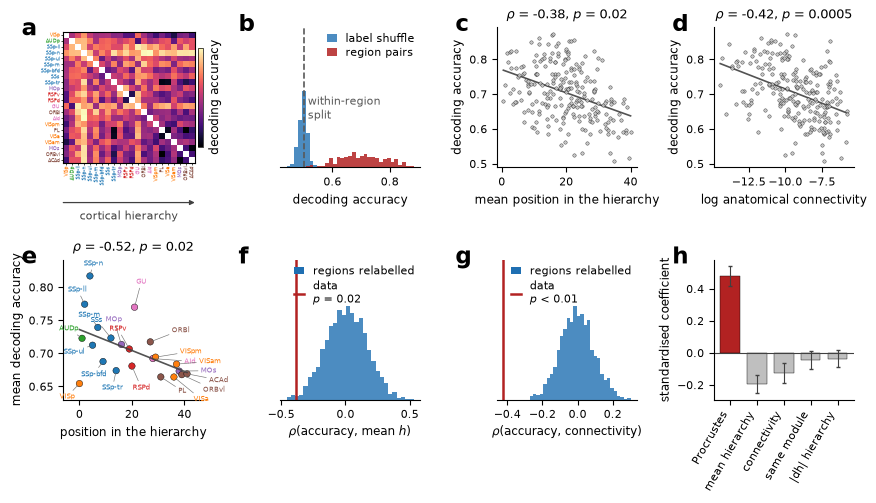

In [9]:
# 2 x 4.  Row 1 is what the decoder finds and how it relates to the two
# anatomical quantities; row 2 is the same relations tested and resolved --
# per-region, each against its region-permutation null, and all of them competing.
# The two anatomical predictors are laid out in the SAME order in both rows
# (hierarchy then connectivity), so a column is one predictor.
PANEL = 2.55
fig = plt.figure(figsize=(4 * PANEL, 2 * PANEL))
gs = fig.add_gridspec(2, 4, wspace=.55, hspace=.45)

ax_mat = fig.add_subplot(gs[0, 0])      # a -- the decoding matrix
ax_acc = fig.add_subplot(gs[0, 1])      # b -- accuracies against the shuffle
ax_pair = fig.add_subplot(gs[0, 2])     # c -- accuracy vs height in the hierarchy
ax_conn = fig.add_subplot(gs[0, 3])     # d -- accuracy vs anatomical connectivity
ax_reg = fig.add_subplot(gs[1, 0])      # e -- per-region decodability vs hierarchy
ax_null = fig.add_subplot(gs[1, 1])     # f -- the hierarchy rho against its null
ax_nullc = fig.add_subplot(gs[1, 2])    # g -- the connectivity rho against its null
ax_beta = fig.add_subplot(gs[1, 3])     # h -- the competing coefficients

# a -- one entry per pair, regions ordered from sensory to associative
plotting.distmat(A, d, ax=ax_mat, cb_label="decoding accuracy",
                 axis_note="cortical hierarchy")

# b -- where the pairs sit relative to a shuffle of the same folds
bins = np.linspace(min(chance.min(), acc.min()) - .01, acc.max() + .01, 34)
ax_acc.hist(chance, bins=bins, color=plotting.NULLC, alpha=.8, label="label shuffle")
ax_acc.hist(acc, bins=bins, color=plotting.OBS, alpha=.85, label="region pairs")
ax_acc.axvline(floor.mean(), color="0.35", lw=1.2, ls="--")
ax_acc.set(xlabel="decoding accuracy", yticks=[])
# more headroom than the module's default: the null is a tall narrow spike, so a
# legend at HEADROOM still lands on top of it
ax_acc.set_ylim(0, ax_acc.get_ylim()[1] * 1.75)
ax_acc.text(floor.mean(), ax_acc.get_ylim()[1] * .52, " within-region\n split",
            fontsize=plotting.FS_ANNOT - 1, color="0.35", va="top", ha="left")
# upper RIGHT, unlike the module's default: the null is a tall spike at the left
# edge of this panel and a legend above it either clips it or wastes half the axes
ax_acc.legend(frameon=False, fontsize=plotting.FS_ANNOT, loc="upper right",
              handlelength=.9, labelspacing=.2, borderaxespad=.1)
ax_acc.set_box_aspect(1)
sns.despine(ax=ax_acc, left=True)

# c -- one point per pair.  Height in the hierarchy, not distance along it: the
# distance is the quantity that does NOT predict decodability (panel f, and
# section 2), so the panel shows the relation that is there
plotting.scatter(mh, acc, "mean position in the hierarchy", "decoding accuracy", ax=ax_pair,
                 title=r"$\rho$ = %+.2f, $p$ = %.2f" % (rho_mh, p_mh))

# d -- the other pair-level anatomical quantity, same treatment as c
plotting.scatter(conn, acc, "log anatomical connectivity", "decoding accuracy", ax=ax_conn,
                 title=r"$\rho$ = %+.2f, $p$ = %.4f" % (rho_conn, p_conn))

# e -- one point per region, coloured by module as everywhere else
plotting.points(ax_reg, h, dec, c=plotting.colors(d), size=plotting.MARKER_SIZE)
plotting.fit_line(ax_reg, h, dec)
ax_reg.set(xlabel="position in the hierarchy", ylabel="mean decoding accuracy")
ax_reg.set_title(r"$\rho$ = %+.2f, $p$ = %.2f" % (rho_reg, p_reg))
ax_reg.margins(.15)          # room for the offset labels near the edges
ax_reg.set_box_aspect(1)
sns.despine(ax=ax_reg)
ax_reg.figure.canvas.draw()
plotting.label_points(ax_reg, h, dec, d.regions, fontsize=plotting.FS_ANNOT - 3,
                      colors=plotting.colors(d))

# f, g -- each pair-level correlation against relabelled regions.  Same null,
# drawn twice rather than once with two lines: the two statistics have different
# null distributions, and overlaying them would imply they share one
plotting.null_hist(ax_null, rho_mh, null_mh, r"$\rho$(accuracy, mean $h$)",
                   label_null="regions relabelled", label_obs="data", p=p_mh,
                   loc="upper right")
plotting.null_hist(ax_nullc, rho_conn, null_conn, r"$\rho$(accuracy, connectivity)",
                   label_null="regions relabelled", label_obs="data", p=p_conn,
                   loc="upper right")

# h -- what survives when the predictors compete
plotting.coefficients(ax_beta, beta, se, NAMES, pvals, alpha=.05 / len(NAMES))

for ax, letter in zip([ax_mat, ax_acc, ax_pair, ax_conn, ax_reg, ax_null,
                       ax_nullc, ax_beta], "abcdefgh"):
    plotting.panel_letter(ax, letter)
plotting.typeset(fig)
plotting.save(fig, "pair_decoding", folder=str(OUT))
plt.show()

**a** Cross-validated accuracy at telling a single neuron of one region from a single neuron of
the other, for all 231 pairs, with the regions ordered from sensory to associative.
**b** The same accuracies against a permutation of the labels through the same folds; the dashed
line is an arbitrary split of a region against itself. **c** Decodability falls as a pair sits
higher in the hierarchy, and **d** as the two regions are more strongly wired together.
**e** The hierarchy relation one level up, one point per region, against how well that region can
be told from all the others. **f**, **g** The correlations of **c** and **d** against a null that
relabels the regions -- the null the 231 non-independent pairs require, and which costs the
hierarchy result four orders of magnitude of $p$ relative to a naive Spearman. **h** Standardised
coefficients of the five predictors fitted together; firebrick is past Bonferroni. Both
anatomical effects are real on their own (**c**, **d**) yet neither survives here, because both
run through the population shape distance rather than beside it.